# Task assignment


Consider an assignment problem where the goal is to assign n workers to n tasks such that the total cost is minimized. The problem can be formulated as:

$$ \min_x \sum_{i=1}^{n} \sum_{j=1}^{n} c_{ij} x_{ij} $$ $$ \sum_{j=1}^{n} x_{ij} = 1, \qquad \forall i \in \{ 1, \dots , n \} \\ \sum_{i=1}^{n} x_{ij} = 1, \qquad \forall j \in \{ 1, \dots , n \} \\ x_{ij} \in \{ 0, 1 \}, \qquad \forall i,j \in \{ 1, \dots , n \} $$

where $c_{ij}$ is the cost of assigning worker $i$ to task $j$.
Furthermore, $x_{ij} = 1$ if worker $i$ is assigned to task $j$, and $0$ otherwise.

# Distributionally robust optimization

#### 1. Formulate a Wasserstein distributionally robust optimization (DRO) problem with l1 or l∞ norm for the risk-averse objective function.

**Distributional Assumptions**

We assume that the $c_{ij}$ are independent random variables and satisfy:

$$
c_{ij} \sim \mathcal{N}(\mu_{ij}, \sigma_{ij}^2) = \mathbb{P}_{ij}, \quad \forall i,j.
$$

The parameters are defined as:
$$
\mu_{ij} = (n+1)i + j, \qquad
\sigma_{ij} = 1 + (n+1)i + j.
$$

**Formulation of Wasserstein distributionally robust optimization**

We flatten matrix $C_{n \times n}$ and $X_{n \times n}$ into vectors in then following way:
$$
\sum_{i=1}^{n} \sum_{j=1}^{n} c_{ij} x_{ij} = \mathbf{c}^{\top} \mathbf{x}
\\
\mathbf{c} = [c_1, c_2, \ldots, c_n]^\top \in \mathbb{R}^{n^2}
\\
\mathbf{x} = [x_1, x_2, \ldots, x_n]^\top \in \{0, 1\}^{n^2}
$$

Then, we can use general formulation of Risk-Averse Distributionally Robust Optimization(DRO):
$$
\min_{\mathbf{x} \in X, t \in \mathbb{R}} \max_{\mathbb{P} \in \mathcal{P}} \left\{ t + \frac{1}{1 - \alpha} \mathbb{E}_{\mathbb{P}} \left\{ \max \{\mathbf{c}^{\top} \mathbf{x} - t, 0 \} \right\} \right\}
$$

where

$$
U = \{\mathbf{c} \in \mathbb{R}^{n^2} : \mathbf{D}\mathbf{c} \leq \mathbf{g}\}
\\
\hat{C}_{train} = \{\hat{\mathbf{c}}^{(k)},\ k \in \{1, \dots, K\}\} \\
\mathcal{P} := \left\{\mathbb{P} : \mathbb{P}\{\mathbf{c} \in U\} = 1 \ \text{and} \ d_W(\hat{\mathbb{P}}_0, \mathbb{P}) \leq \varepsilon \right\}
\\
\hat{\mathbb{P}}_0(\hat{C}_{train}) := \frac{1}{K} \sum_{k=1}^K \delta_{\hat{\mathbf{c}}^{(k)}}
$$

It can be simplified to:
$$
\begin{align}
\min_{\mathbf{x}, \boldsymbol{\nu}, \mathbf{s}, \lambda, t} & \left\{ t + \frac{1}{1 - \alpha} \left( \lambda \varepsilon + \frac{1}{K} \sum_{k=1}^K s_k \right) \right\}
\\
\text{s.t.} \quad & \mathbf{x} \in \{0, 1\}^{n^2}
\\
& \lambda \ge 0
\\
& \hat{\mathbf{c}}^{(k)\top} \mathbf{x} - t + \boldsymbol{\Delta}^{(k)\top} \boldsymbol{\nu}^{(k)} \le s_k, \quad \forall k \in \{1, \dots, K\}, \nonumber
\\
& \| \mathbf{D}^\top \boldsymbol{\nu}^{(k)} - \mathbf{x} \|_{∞} \le \lambda, \quad \forall k \in \{1, \dots, K\}, \Longleftrightarrow -\lambda \leq \left( \mathbf{D}^\top \boldsymbol{\nu}^{(k)} - \mathbf{x} \right)_i \leq \lambda, \quad \forall i = \overline{1, n^2} \quad \forall k \in \{1, \dots, K\}, \nonumber
\\
& \boldsymbol{\nu}^{(k)} \ge 0, \ s_k \ge 0, \quad \forall k \in \{1, \dots, K\}
\end{align}
$$
where $\boldsymbol{\Delta}^{(k)} = \mathbf{g} - \mathbf{D}\hat{\mathbf{c}}^{(k)} \ge 0$ for each $k \in \{1, \dots, K\}$


In [26]:
import json
import gurobipy as gp
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

GUROBI_CONF_PATH = "./gurobi_conf.json"


def set_environ(environ: gp.Env, conf_path: str = GUROBI_CONF_PATH):
    with open(conf_path, "r") as cfp:
        configuration = json.load(cfp)

    access_id = configuration["environ"].get("WLSAccessID")
    secret = configuration["environ"].get("WLSSecret")
    licence_id = configuration["environ"].get("LicenseID")

    print(f"NOTE: Got environment configuration parameters:\nWLSAccessID: {access_id},\nWLSSecret: {secret},\nLicenseID: {licence_id}\n")
    if all([access_id, secret, licence_id]):
        print(f"NOTE: found existing Gurobi licence")
        environ.setParam('WLSAccessID', access_id)
        environ.setParam('WLSSecret', secret)
        environ.setParam('LicenseID', licence_id)
    else:
        print(f"WARNING: some of the environment configuration parameters are None - using free Gurobi licence: you will not be able to solve large problems!")


def set_model_params(model: gp.Model, conf_path: str = GUROBI_CONF_PATH):
    with open(conf_path, "r") as cfp:
        configuration = json.load(cfp)

    output_flag = configuration["model"].get("OutputFlag", 0)
    log_to_console = configuration["model"].get("LogToConsole", 0)

    model.setParam("OutputFlag", output_flag)
    model.setParam("LogToConsole", log_to_console)

In [27]:
import numpy as np
from gurobipy import GRB


def build_box_uncertainty(samples):
    # bounds chosen by samples min/max
    l = samples.min(axis=0)
    u = samples.max(axis=0)
    dim = len(l)
    D = np.vstack([np.eye(dim), -np.eye(dim)])
    g = np.hstack([u, -l])
    return D, g


def assignment_constraints(model, x, n):
    def idx(i, j):
        return i * n + j

    for i in range(n):
        model.addConstr(sum(x[idx(i, j)] for j in range(n)) == 1)

    for j in range(n):
        model.addConstr(sum(x[idx(i, j)] for i in range(n)) == 1)


class DROAssignment:
    def __init__(self, n, epsilon, alpha, D, g, env):
        self.n = n
        self.epsilon = epsilon
        self.alpha = alpha
        self.D = D
        self.g = g
        self.env = env

    def solve(self, samples):
        K, dim = samples.shape
        n = self.n

        model = gp.Model("DRO_Assignment", env=self.env)
        set_model_params(model)

        # variables
        x = model.addVars(dim, vtype=GRB.BINARY, name="x")
        t = model.addVar(lb=-GRB.INFINITY, name="t")
        lam = model.addVar(lb=0, name="lambda")
        s = model.addVars(K, lb=0, name="s")

        nu = {}
        for k in range(K):
            nu[k] = model.addVars(self.D.shape[0], lb=0, name=f"nu_{k}")

        # assignment constraints
        assignment_constraints(model, x, n)

        # DRO constraints
        for k in range(K):
            c_k = samples[k]

            # Delta_k = g - D c_k
            Delta_k = self.g - self.D @ c_k

            # main constraint
            model.addConstr(
                gp.quicksum(c_k[i] * x[i] for i in range(dim))
                - t
                + gp.quicksum(Delta_k[j] * nu[k][j] for j in range(len(Delta_k)))
                <= s[k]
            )

            # infinity norm constraints
            for i in range(dim):
                expr = (
                    gp.quicksum(self.D[j, i] * nu[k][j] for j in range(self.D.shape[0]))
                    - x[i]
                )
                model.addConstr(expr <= lam)
                model.addConstr(expr >= -lam)

        # objective
        model.setObjective(
            t + (1 / (1 - self.alpha)) * (lam * self.epsilon + (1 / K) * gp.quicksum(s[k] for k in range(K))),
            GRB.MINIMIZE
        )

        model.optimize()

        x_sol = np.array([x[i].X for i in range(dim)])
        t_val = t.X
        return x_sol.reshape((n, n)), model.objVal, t_val

#### 2. For each n ∈ {5, 10, . . . , 50}, generate 100 test instances of the problem by using k = 30 samples from the true distribution.

In [28]:
class DRODataGenerator:
    def __init__(self, seed=42):
        """
        Initialize random number generator for reproducibility.
        """
        self.rng = np.random.default_rng(seed)

    def generate_samples(self, n, K):
        """
        Generate K samples from the true distribution P*.

        Each sample corresponds to a cost matrix C (n x n),
        which is flattened into a vector of length n^2.

        Distribution:
            c_ij ~ N(mu_ij, sigma_ij^2)

        where:
            mu_ij = (n+1)*i + j
            sigma_ij = 1 + (n+1)*i + j

        Parameters:
            n (int): number of workers/tasks
            K (int): number of samples

        Returns:
            samples (np.ndarray): shape (K, n^2)
        """
        M = n + 1
        samples = []

        for _ in range(K):
            C = np.zeros((n, n))

            for i in range(n):
                for j in range(n):
                    # Note: using (i+1), (j+1) for 1-based indexing
                    mu = M * (i + 1) + (j + 1)
                    sigma = 1 + M * (i + 1) + (j + 1)

                    # Draw from normal distribution
                    C[i, j] = self.rng.normal(mu, sigma)

            # Flatten matrix into vector
            samples.append(C.flatten())

        return np.array(samples)  # shape: (K, n^2)

    def generate_experiment(self, n_values, num_instances=100, K=30):
        """
        Generate full experimental dataset.

        For each n in n_values:
            - create num_instances independent problem instances
            - each instance consists of K samples

        Parameters:
            n_values (list): list of problem sizes (e.g., [5, 10, ..., 50])
            num_instances (int): number of instances per n
            K (int): number of samples per instance

        Returns:
            data (dict):
                data[n] = list of instances
                each instance has shape (K, n^2)
        """
        data = {}

        for n in n_values:
            instances = []

            for _ in range(num_instances):
                samples = self.generate_samples(n, K)
                instances.append(samples)

            data[n] = instances

        return data

#### 3. Explore the dependence of the average out-of-sample performance (with standard deviations) on the Wasserstein radius, ε. Find the critical Wasserstein radius ε∗ that minimizes the theoretical out-of-sample performance.

In [29]:
def compute_true_optimum(samples, n, alpha, env):
    K, dim = samples.shape

    model = gp.Model(env=env)
    set_model_params(model)

    # Variables
    x = model.addVars(dim, vtype=GRB.BINARY, name="x")
    t = model.addVar(lb=-GRB.INFINITY, name="t")
    z = model.addVars(K, lb=0, name="z")

    # Assignment constraints
    assignment_constraints(model, x, n)

    # CVaR constraints: z_k >= c_k^T x - t
    for k in range(K):
        model.addConstr(
            z[k] >= gp.quicksum(samples[k][i] * x[i] for i in range(dim)) - t
        )

    # Objective (SAA CVaR)
    model.setObjective(
        t + (1 / (1 - alpha)) * (1 / K) * gp.quicksum(z[k] for k in range(K)),
        GRB.MINIMIZE
    )

    model.optimize()

    return model.objVal

In [30]:
def evaluate_out_of_sample(samples, x_opt, t_opt, alpha):
    x = x_opt.flatten()

    costs = samples @ x

    losses = t_opt + (1 / (1 - alpha)) * np.maximum(costs - t_opt, 0)

    return np.mean(losses)

In [31]:
def append_result_to_json(path: Path, n, k, eps, mean_rho, std_rho, time):
    path = Path(path)
    path.parent.mkdir(exist_ok=True, parents=True)

    if path.exists():
        with open(path, "r") as f:
            data = json.load(f)
    else:
        data = {}

    n_key = str(n)

    if n_key not in data:
        data[n_key] = []

    data[n_key].append({
        "k": k,
        "epsilon": float(eps),
        "mean_rho": float(mean_rho),
        "std_rho": float(std_rho),
        "time": time
    })

    with open(path, "w") as f:
        json.dump(data, f, indent=4)

In [32]:
import time
def run_eps_estimation(env, generator, n_values, eps_grid,
                       num_instances=20, K_train=30, K_test=1000,
                       json_path="task3_results.json"):
    results = {}
    for n in n_values:
        print(f"\n=== n = {n} ===")

        eps_results = {eps: [] for eps in eps_grid}

        for instance_id in tqdm(range(num_instances)):
            train = generator.generate_samples(n, K_train)
            test = generator.generate_samples(n, K_test)

            z_star = compute_true_optimum(test, n, 0.95, env)
            D, g = build_box_uncertainty(train)

            for eps in eps_grid:

                solver = DROAssignment(
                    n=n,
                    epsilon=eps,
                    alpha=0.95,
                    D=D,
                    g=g,
                    env=env
                )
                start = time.perf_counter()
                x_hat, obj, t_hat = solver.solve(train)
                end = time.perf_counter()

                out_sample = evaluate_out_of_sample(test, x_hat, t_hat, alpha=0.95)

                rho = out_sample / z_star
                eps_results[eps].append(rho)

        results[n] = []

        for eps in eps_grid:
            mean_rho = np.mean(eps_results[eps])
            std_rho = np.std(eps_results[eps])

            results[n].append((mean_rho, std_rho, eps))

            append_result_to_json(
                json_path,
                n,
                K_train,
                eps,
                mean_rho,
                std_rho,
                end-start
            )

    return results

In [33]:
def plot_results(results, eps_grid, n_values):
    plt.figure(figsize=(10, 6))

    for n in n_values:
        means = [r[0] for r in results[n]]
        stds = [r[1] for r in results[n]]

        plt.errorbar(eps_grid, means, yerr=stds, label=f"n={n}")

    plt.xlabel("Wasserstein radius ε")
    plt.ylabel("ρ_out")
    plt.title("Out-of-sample performance vs ε")
    plt.legend()
    plt.grid()
    plt.show()

In [34]:
env = gp.Env(empty=True)
set_environ(env)
env.start()

generator = DRODataGenerator(seed=1)

NOTE: Got environment configuration parameters:
WLSAccessID: c883e76c-6b5d-4a16-9dc8-dd44f341af22,
WLSSecret: 1721a792-2ef0-4ae2-a7c7-993621b5fcca,
LicenseID: 2799306

NOTE: found existing Gurobi licence
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2799306


GurobiError: Unexpected response (status 451, command POST https://token.gurobi.com/api/v1/tokens)

In [ ]:
n_values = [5]
eps_grid = np.linspace(0.0, 10.0, 12)

results = run_eps_estimation(
    env=env,
    generator=generator,
    n_values=n_values,
    eps_grid=eps_grid,
    num_instances=10,
    K_train=30,
    K_test=200,
    json_path="./optimal_eps_estimation/eps_for_n5.json",
)
plot_results(results, eps_grid, n_values)


=== n = 5 ===


 10%|█         | 1/10 [00:06<01:00,  6.69s/it]


KeyboardInterrupt: 


=== n = 10 ===


100%|██████████| 5/5 [04:43<00:00, 56.67s/it]


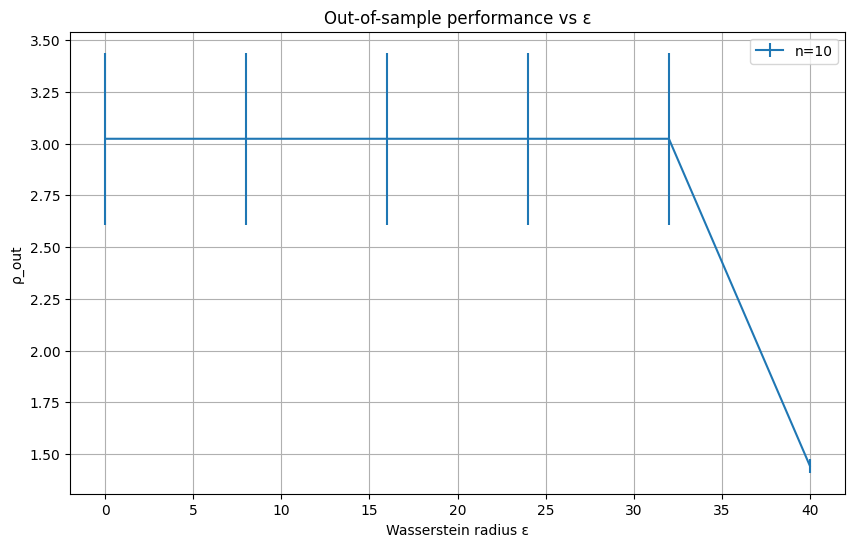

In [ ]:
n_values = [10]
eps_grid = np.linspace(0.0, 40.0, 6)

results = run_eps_estimation(
    env=env,
    generator=generator,
    n_values=n_values,
    eps_grid=eps_grid,
    num_instances=5,
    K_train=15,
    K_test=200,
    json_path="./optimal_eps_estimation/eps_for_n10_0-40.json",
)
plot_results(results, eps_grid, n_values)

In [ ]:
n_values = [15]
eps_grid = np.linspace(20.0, 100.0, 6)

results = run_eps_estimation(
    env=env,
    generator=generator,
    n_values=n_values,
    eps_grid=eps_grid,
    num_instances=2,
    K_train=15,
    K_test=200,
    json_path="./optimal_eps_estimation/eps_for_n15_20-100.json",
)
plot_results(results, eps_grid, n_values)


=== n = 15 ===


 50%|█████     | 1/2 [32:38<32:38, 1958.96s/it]


GurobiError: Could not resolve host: token.gurobi.com (code 6, command POST https://token.gurobi.com/api/v1/tokens)

In [ ]:
env.close()

#### 4. Find the average critical Wasserstein radius using cross validation (holdout method and/or k-fold cross validation [3]) and compare this radius with the theoretical estimate ε∗.

In [ ]:
def kfold_split(samples, k_folds):
    K = len(samples)
    indices = np.arange(K)
    np.random.shuffle(indices)

    folds = np.array_split(indices, k_folds)

    splits = []
    for i in range(k_folds):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k_folds) if j != i])

        train_fold = samples[train_idx]
        val_fold = samples[val_idx]

        splits.append((train_fold, val_fold))

    return splits

In [ ]:
def select_epsilon_cv(samples, n, eps_grid, env, alpha=0.95, k_folds=3):
    splits = kfold_split(samples, k_folds)

    eps_scores = {eps: [] for eps in eps_grid}

    for eps in eps_grid:
        for train_fold, val_fold in splits:

            D, g = build_box_uncertainty(train_fold)

            solver = DROAssignment(
                n=n,
                epsilon=eps,
                alpha=alpha,
                D=D,
                g=g,
                env=env
            )

            x_hat, obj, t_hat = solver.solve(train_fold)

            val_loss = evaluate_out_of_sample(val_fold, x_hat, t_hat, alpha)
            eps_scores[eps].append(val_loss)

    # усредняем
    eps_mean = {
        eps: np.mean(eps_scores[eps])
        for eps in eps_grid
    }

    # выбираем лучший ε
    best_eps = min(eps_mean, key=eps_mean.get)

    return best_eps, eps_mean

In [ ]:
def run_cross_validation(env, generator, n_values, eps_grid,
                         num_instances=20, K=30, k_folds=3):

    results = {}

    for n in n_values:
        print(f"\n=== n = {n} ===")

        eps_star_list = []

        for instance_id in tqdm(range(num_instances)):

            samples = generator.generate_samples(n, K)

            eps_star, _ = select_epsilon_cv(
                samples=samples,
                n=n,
                eps_grid=eps_grid,
                env=env,
                k_folds=k_folds
            )

            eps_star_list.append(eps_star)

        avg_eps = np.mean(eps_star_list)
        std_eps = np.std(eps_star_list)

        results[n] = {
            "eps_star_mean": avg_eps,
            "eps_star_std": std_eps,
            "all_eps": eps_star_list
        }

        print(f"avg eps*: {avg_eps:.4f} ± {std_eps:.4f}")

    return results

In [ ]:
env = gp.Env(empty=True)
set_environ(env)
env.start()

generator = DRODataGenerator(seed=1)

In [ ]:
n_values = [5]
eps_grid = np.linspace(0, 10.0, 6)
num_instances = 20
K = 30
k_folds = 3

In [ ]:
cv_results = run_cross_validation(
    env=env,
    generator=generator,
    n_values=n_values,
    eps_grid=eps_grid,
    num_instances=num_instances,
    K=K,
    k_folds=k_folds
)

for n in cv_results:
    print(f"\nn = {n}")
    print(f"eps*_mean = {cv_results[n]['eps_star_mean']:.4f}")
    print(f"eps*_std  = {cv_results[n]['eps_star_std']:.4f}")

In [ ]:
n_values = [10]
eps_grid = np.linspace(10.0, 35.0, 6)
num_instances = 20
K = 30
k_folds = 3

In [ ]:
cv_results = run_cross_validation(
    env=env,
    generator=generator,
    n_values=n_values,
    eps_grid=eps_grid,
    num_instances=num_instances,
    K=K,
    k_folds=k_folds
)

for n in cv_results:
    print(f"\nn = {n}")
    print(f"eps*_mean = {cv_results[n]['eps_star_mean']:.4f}")
    print(f"eps*_std  = {cv_results[n]['eps_star_std']:.4f}")

#### 5. Explore how the critical Wasserstein radius ε∗ depends on the sample size, k.

In [ ]:
import time

def find_critical_epsilon(eps_grid, performance_values):
    """
    Находит критическое значение ε*, минимизирующее out-of-sample performance.
    
    Parameters:
    -----------
    eps_grid : np.ndarray
        Массив значений ε
    performance_values : np.ndarray
        Массив средних значений out-of-sample performance (ρ_out)
    
    Returns:
    --------
    epsilon_star : float
        Критическое значение ε
    """
    # Находим индекс минимального значения performance
    min_idx = np.argmin(performance_values)
    epsilon_star = eps_grid[min_idx]
    
    # Дополнительно: квадратичная интерполяция для более точного определения
    if 0 < min_idx < len(eps_grid) - 1:
        # Используем параболическую интерполяцию
        x = eps_grid[min_idx-1:min_idx+2]
        y = performance_values[min_idx-1:min_idx+2]
        
        # Коэффициенты квадратичного полинома
        coeffs = np.polyfit(x, y, 2)
        
        # Вершина параболы
        if coeffs[0] != 0:
            epsilon_star_interp = -coeffs[1] / (2 * coeffs[0])
            # Ограничиваем интерполяцию разумными пределами
            if x[0] <= epsilon_star_interp <= x[2]:
                epsilon_star = epsilon_star_interp
    
    return epsilon_star


def explore_epsilon_vs_sample_size(
    env,
    generator,
    n_fixed=10,                    # фиксированный размер задачи
    k_values=[5, 10, 20, 30, 50, 75, 100, 150, 200],# размеры выборки для исследования
    eps_grid=None,                 # сетка ε (если None, будет создана автоматически)
    num_instances=20,              # количество тестовых инстансов для каждого k
    K_test=500,                    # размер тестовой выборки
    alpha=0.95                     # уровень доверия CVaR
):
    """
    Исследует зависимость критического радиуса Вассерштейна ε* от размера выборки k.
    
    Parameters:
    -----------
    env : Gurobi environment
    generator : DRODataGenerator
        Генератор данных
    n_fixed : int
        Фиксированный размер задачи (n)
    k_values : list
        Список размеров выборки для исследования
    eps_grid : np.ndarray or None
        Сетка значений ε
    num_instances : int
        Количество инстансов для усреднения
    K_test : int
        Размер тестовой выборки
    alpha : float
        Уровень доверия CVaR
    
    Returns:
    --------
    results : dict
        Словарь с результатами для каждого k
    """
    
    if eps_grid is None:
        # Адаптивная сетка ε в зависимости от k
        eps_grid = np.array([0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0])
    
    results = {}
    
    print(f"Исследование зависимости ε* от размера выборки k")
    print(f"Фиксированный размер задачи n = {n_fixed}")
    print(f"Количество инстансов для каждого k: {num_instances}")
    
    for k_idx, k_train in enumerate(k_values):
        print(f"\n--- Исследуем k = {k_train} ---")
        
        # Для каждого значения ε собираем out-of-sample performance
        eps_performance = []  # (mean_performance, std_performance)
        
        for eps in eps_grid:
            print(f"  ε = {eps:.1f}", end=" ", flush=True)
            
            rho_instances = []
            solve_times = []
            
            for instance_id in tqdm(range(num_instances), desc=f"    k={k_train}, ε={eps}", leave=False):
                # Генерируем обучающую и тестовую выборки
                train_samples = generator.generate_samples(n_fixed, k_train)
                test_samples = generator.generate_samples(n_fixed, K_test)
                
                # Строим uncertainty set
                D, g = build_box_uncertainty(train_samples)
                
                # Решаем DRO задачу
                start_time = time.time()
                solver = DROAssignment(
                    n=n_fixed,
                    epsilon=eps,
                    alpha=alpha,
                    D=D,
                    g=g,
                    env=env
                )
                x_opt, obj_val, t_opt = solver.solve(train_samples)
                solve_time = time.time() - start_time
                solve_times.append(solve_time)
                
                # Оцениваем out-of-sample performance
                # Используем t из решения (obj_val) для CVaR
                rho = evaluate_out_of_sample(test_samples, x_opt, t_opt, alpha=alpha)
                rho_instances.append(rho)
            
            mean_rho = np.mean(rho_instances)
            std_rho = np.std(rho_instances)
            mean_time = np.mean(solve_times)
            eps_performance.append((mean_rho, std_rho, mean_time))
            
            print(f"ρ = {mean_rho:.4f} ± {std_rho:.4f}, время = {mean_time:.2f}s")
        
        # Находим критическое ε* для данного k
        means = [p[0] for p in eps_performance]
        epsilon_star = find_critical_epsilon(eps_grid, np.array(means))
        
        results[k_train] = {
            'eps_grid': eps_grid,
            'performance': eps_performance,
            'epsilon_star': epsilon_star,
            'solve_times': [p[2] for p in eps_performance]
        }
        
        print(f"\n  >>> Для k = {k_train}: ε* ≈ {epsilon_star:.4f}")
    
    return results


def plot_epsilon_star_vs_sample_size(results, n_fixed, theoretical_fit=True):
    """
    Строит график зависимости ε* от размера выборки k.
    
    Parameters:
    -----------
    results : dict
        Результаты из функции explore_epsilon_vs_sample_size
    n_fixed : int
        Размер задачи (для подписи)
    theoretical_fit : bool
        Добавить ли теоретическую аппроксимацию ε* ~ 1/√k
    """
    
    k_values = sorted(results.keys())
    epsilon_stars = [results[k]['epsilon_star'] for k in k_values]
    
    plt.figure(figsize=(10, 6))
    
    # Основной график
    plt.plot(k_values, epsilon_stars, 'bo-', linewidth=2, markersize=8, label='ε* (эксперимент)')
    plt.xlabel('Размер выборки k', fontsize=12)
    plt.ylabel('Критический радиус ε*', fontsize=12)
    plt.title(f'Зависимость ε* от размера выборки (n = {n_fixed})', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Теоретическая аппроксимация ε* ~ C/√k
    if theoretical_fit and len(k_values) >= 2:
        # Используем только точки с ε* > 0 для подбора
        valid_idx = [i for i, eps in enumerate(epsilon_stars) if eps > 0]
        if len(valid_idx) >= 2:
            k_valid = [k_values[i] for i in valid_idx]
            eps_valid = [epsilon_stars[i] for i in valid_idx]
            
            # Подбираем константу C
            C = np.mean([eps * np.sqrt(k) for eps, k in zip(eps_valid, k_valid)])
            k_theor = np.linspace(min(k_values), max(k_values), 100)
            eps_theor = C / np.sqrt(k_theor)
            
            plt.plot(k_theor, eps_theor, 'r--', linewidth=2, 
                    label=f'Теоретическая: ε* = {C:.2f}/√k')
    
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_epsilon_star_convergence(results, n_fixed):
    """
    Строит график сходимости ε* с ростом выборки.
    """
    k_values = sorted(results.keys())
    epsilon_stars = [results[k]['epsilon_star'] for k in k_values]
    
    plt.figure(figsize=(10, 6))
    
    # Основной график
    plt.plot(k_values, epsilon_stars, 'gs-', linewidth=2, markersize=8, label='ε*')
    
    # Горизонтальная линия на уровне 0
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Асимптота (ε*=0)')
    
    plt.xlabel('Размер выборки k', fontsize=12)
    plt.ylabel('Критический радиус ε*', fontsize=12)
    plt.title(f'Сходимость ε* с ростом выборки (n = {n_fixed})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Запуск исследования
def run_task_5():
    """
    Запуск полного исследования для пункта 5.
    """
    # Инициализация окружения Gurobi
    env = gp.Env(empty=True)
    set_environ(env)
    env.start()
    
    # Создание генератора данных
    generator = DRODataGenerator(seed=42)
    
    # Параметры исследования
    n_fixed = 5  # фиксированный размер задачи
    
    # Размеры выборки для исследования
    k_values = [5, 10]
    
    # Сетка значений ε
    eps_grid = np.array([0.0, 10.0, 20.0, 30.0, 40.0])
    
    # Количество инстансов
    num_instances = 10
    K_test = 200
    
    print("ПУНКТ 5: Исследование зависимости критического радиуса ε* от размера выборки k")
    print(f"Параметры:")
    print(f"  - Размер задачи n = {n_fixed}")
    print(f"  - Исследуемые k: {k_values}")
    print(f"  - Сетка ε: {eps_grid}")
    print(f"  - Количество инстансов: {num_instances}")
    print(f"  - Размер тестовой выборки: {K_test}")
    
    # Запуск исследования
    results = explore_epsilon_vs_sample_size(
        env=env,
        generator=generator,
        n_fixed=n_fixed,
        k_values=k_values,
        eps_grid=eps_grid,
        num_instances=num_instances,
        K_test=K_test,
        alpha=0.95
    )
    
    # Закрываем окружение
    env.close()
    
    # Визуализация результатов
    plot_epsilon_star_vs_sample_size(results, n_fixed, theoretical_fit=True)
    plot_epsilon_star_convergence(results, n_fixed)
    
    # Вывод таблицы результатов
    print("\nСводная таблица результатов:")
    print(f"{'k':<10} {'ε*':<15} {'Минимальное ρ':<20}")
    for k in sorted(results.keys()):
        eps_star = results[k]['epsilon_star']
        min_rho = min([p[0] for p in results[k]['performance']])
        print(f"{k:<10} {eps_star:<15.6f} {min_rho:<20.6f}")
    
    return results


# Пример запуска
results = run_task_5()

# Дополнительная функция: сравнение ε* для разных n
def compare_epsilon_star_for_different_n(
    env,
    generator,
    n_values=[5, 10, 15, 20],
    k_values=[10, 20, 30, 50, 100],
    eps_grid=None,
    num_instances=10
):
    """
    Сравнение зависимости ε*(k) для разных размеров задачи n.
    """
    if eps_grid is None:
        eps_grid = np.array([0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0])
    
    results_by_n = {}
    
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(n_values)))
    
    for n, color in zip(n_values, colors):
        print(f"\n=== Исследование для n = {n} ===")
        
        results = explore_epsilon_vs_sample_size(
            env=env,
            generator=generator,
            n_fixed=n,
            k_values=k_values,
            eps_grid=eps_grid,
            num_instances=num_instances,
            K_test=300,
            alpha=0.95
        )
        
        results_by_n[n] = results
        
        # Строим линию для данного n
        k_list = sorted(results.keys())
        eps_star_list = [results[k]['epsilon_star'] for k in k_list]
        plt.plot(k_list, eps_star_list, 'o-', linewidth=2, markersize=6, 
                color=color, label=f'n = {n}')
    
    plt.xlabel('Размер выборки k', fontsize=12)
    plt.ylabel('Критический радиус ε*', fontsize=12)
    plt.title('Зависимость ε* от k для разных размеров задачи n', fontsize=14)
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return results_by_n

# Для сравнения разных n (более ресурсоемко)
# results_by_n = compare_epsilon_star_for_different_n(env, generator)

#### 6. For fixed n, compute the average solution times as a function of ε.

In [ ]:
import time
import matplotlib.pyplot as plt


def average_solution_time_vs_epsilon(
    n_fixed=10,
    epsilon_grid=None,
    num_instances=100,
    K=30,
    alpha=0.95,
    seed=123,
    show_progress=True,
):
    """
    Compute the average DRO solution time as a function of the Wasserstein radius ε
    for a fixed problem size n.

    The same randomly generated instances are reused for all ε values so that the
    comparison is fair. Sample generation and uncertainty-set construction are done
    once in advance and are NOT included in the measured time.
    """
    if epsilon_grid is None:
        epsilon_grid = np.linspace(0.0, 2.0, 9)

    epsilon_grid = np.asarray(epsilon_grid, dtype=float)
    generator = DRODataGenerator(seed=seed)

    # Pre-generate all instances
    instances = []
    for _ in range(num_instances):
        samples = generator.generate_samples(n_fixed, K=K)
        D, g = build_box_uncertainty(samples)
        instances.append((samples, D, g))

    mean_times = []
    std_times = []
    raw_times = {float(eps): [] for eps in epsilon_grid}

    # Reuse one Gurobi environment
    env = gp.Env(empty=True)
    set_environ(env)
    env.start()

    try:
        for eps in epsilon_grid:
            if show_progress:
                print(f"Solving for epsilon = {eps:.4f}")

            current_times = []

            for instance_id, (samples, D, g) in enumerate(instances, start=1):
                solver = DROAssignment(
                    n=n_fixed,
                    epsilon=float(eps),
                    alpha=alpha,
                    D=D,
                    g=g,
                    env=env
                )

                start_time = time.perf_counter()
                _x_opt, _obj = solver.solve(samples)
                elapsed = time.perf_counter() - start_time

                current_times.append(elapsed)

                if show_progress and instance_id % 10 == 0:
                    print(f"  processed {instance_id}/{num_instances} instances")

            raw_times[float(eps)] = current_times
            mean_times.append(np.mean(current_times))
            std_times.append(np.std(current_times, ddof=1) if len(current_times) > 1 else 0.0)

    finally:
        env.close()

    mean_times = np.asarray(mean_times)
    std_times = np.asarray(std_times)

    plt.figure(figsize=(8, 5))
    plt.plot(epsilon_grid, mean_times, marker='o', linewidth=2, label='Average solution time')
    plt.fill_between(
        epsilon_grid,
        mean_times - std_times,
        mean_times + std_times,
        alpha=0.2,
        label='±1 standard deviation'
    )
    plt.xlabel(r'Wasserstein radius $\varepsilon$')
    plt.ylabel('Average solution time (seconds)')
    plt.title(
        f'Average DRO solution time vs. Wasserstein radius\n'
        f'fixed n = {n_fixed}, K = {K}, instances = {num_instances}'
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return {
        "epsilon_grid": epsilon_grid,
        "mean_times": mean_times,
        "std_times": std_times,
        "raw_times": raw_times,
    }


# Example run
timing_vs_epsilon_results = average_solution_time_vs_epsilon(
    n_fixed=10,
    epsilon_grid=np.linspace(0.0, 2.0, 5),
    num_instances=10,
    K=30,
    alpha=0.95,
    seed=123,
    show_progress=True,
)

print("Mean solution times:", timing_vs_epsilon_results["mean_times"])
print("Std. deviations:", timing_vs_epsilon_results["std_times"])

#### 7. For fixed ε, compute the average solution times as a function of n. Compare the obtained solution times with the SAA (ε = 0) and the robust optimization approach (ε is sufficiently large).

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

def solve_with_epsilon(env, generator, n, epsilon, K_train=30):

    # Решает задачу для заданного n и epsilon, возвращает время решения.

    samples = generator.generate_samples(n, K_train)
    D, g = build_box_uncertainty(samples)
    
    solver = DROAssignment(
        n=n,
        epsilon=epsilon,
        alpha=0.95,
        D=D,
        g=g,
        env=env
    )
    
    start = time.time()
    x_opt, obj = solver.solve(samples)
    elapsed = time.time() - start
    
    return elapsed

def run_task_7(env, generator, n_values, eps_fixed=0.1, eps_large=1e4, num_runs=5):
    # Для каждого n несколько раз решаем задачу при разных ε, усредняем время.
    times_saa = []
    times_dro = []
    times_robust = []
    
    for n in n_values:
        print(f"Processing n = {n}...")
        
        t_saa = []
        t_dro = []
        t_robust = []
        
        for _ in range(num_runs):
            t_saa.append(solve_with_epsilon(env, generator, n, epsilon=0.0))
            t_dro.append(solve_with_epsilon(env, generator, n, epsilon=eps_fixed))
            t_robust.append(solve_with_epsilon(env, generator, n, epsilon=eps_large))
        
        times_saa.append(np.mean(t_saa))
        times_dro.append(np.mean(t_dro))
        times_robust.append(np.mean(t_robust))
    
    return times_saa, times_dro, times_robust

# Параметры эксперимента
n_values_task7 = [5, 10]
num_runs = 3

env = gp.Env(empty=True)
set_environ(env)
env.start()

generator = DRODataGenerator(seed=42)

times_saa, times_dro, times_robust = run_task_7(
    env, generator, n_values_task7, 
    eps_fixed=0.1, eps_large=1e4, 
    num_runs=num_runs
)

env.close()

# Построение графиков
plt.figure(figsize=(12, 5))

# График 1: Зависимость времени от n для фиксированного ε
plt.subplot(1, 2, 1)
plt.plot(n_values_task7, times_dro, marker='o', label=f'DRO (ε=0.1)')
plt.plot(n_values_task7, times_saa, marker='s', label='SAA (ε=0)')
plt.plot(n_values_task7, times_robust, marker='^', label='Robust (ε large)')
plt.xlabel('n (размер задачи)')
plt.ylabel('Среднее время решения (сек)')
plt.title('Зависимость времени решения от n')
plt.legend()
plt.grid(True)

# График 2: Сравнение времени для разных ε при фиксированном n (например, n=15)
idx_n = n_values_task7.index(15)
labels = ['SAA (ε=0)', 'DRO (ε=0.1)', 'Robust (ε large)']
times_at_n15 = [times_saa[idx_n], times_dro[idx_n], times_robust[idx_n]]

plt.subplot(1, 2, 2)
plt.bar(labels, times_at_n15, color=['blue', 'green', 'red'])
plt.ylabel('Время решения (сек)')
plt.title(f'Сравнение подходов при n=15')
plt.grid(axis='y')

plt.tight_layout()
plt.show()

# Вывод численных значений
print("\n=== Среднее время решения (сек) ===")
print("n\tSAA (ε=0)\tDRO (ε=0.1)\tRobust (ε large)")
for i, n in enumerate(n_values_task7):
    print(f"{n}\t{times_saa[i]:.3f}\t\t{times_dro[i]:.3f}\t\t{times_robust[i]:.3f}")